In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent

# 加载模型配置
# 请事先在 .env 中配置 DASHSCOPE_API_KEY
_ = load_dotenv()

c:\Users\jd\.conda\envs\llm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# 配置大模型服务
llm = ChatOpenAI(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url=os.getenv("DEEPSEEK_BASE_URL"),
    model="deepseek-chat",
)

# 创建一个简单的Agent
agent = create_agent(
    model=llm,
    system_prompt="You are a helpful assistant",
)

In [9]:
# 一个工具函数
def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"


In [10]:
from typing import Literal, Any
from pydantic import BaseModel
from langchain.tools import tool, ToolRuntime

class Context(BaseModel):
    authority: Literal["admin", "user"]

# 创建带权限控制的tool，依赖ToolRuntime的内容进行判断
@tool
def math_add(runtime: ToolRuntime[Context, Any], a: int, b: int) -> int:
    """Add two numbers together."""
    authority = runtime.context.authority
    # 只有admin用户可以访问加法工具
    if authority != "admin":
        raise PermissionError("User does not have permission to add numbers")
    return a + b

# 创建带工具调用的Agent
tool_agent = create_agent(
    model=llm,
    tools=[get_weather, math_add],
    system_prompt="You are a helpful assistant",
)

# 在运行Agent时注入context
response = tool_agent.invoke(
    {"messages": [{"role": "user", "content": "请计算 8234783 + 94123832 = ?"}]},
    config={"configurable": {"thread_id": "1"}},
    context=Context(authority="admin"),
)

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

请计算 8234783 + 94123832 = ?
================================== Ai Message ==================================

我来帮您计算 8234783 + 94123832 的和。
Tool Calls:
  math_add (call_00_cM6ZQuYkEqPZtREoQWzYqEhT)
 Call ID: call_00_cM6ZQuYkEqPZtREoQWzYqEhT
  Args:
    a: 8234783
    b: 94123832
================================= Tool Message =================================
Name: math_add

102358615
================================== Ai Message ==================================

8234783 + 94123832 = 102,358,615


In [11]:
from pydantic import BaseModel, Field

class CalcInfo(BaseModel):
    """Calculation information."""
    output: int = Field(description="The calculation result")

# 创建带结构化输出的Agent
structured_agent = create_agent(
    model=llm,
    tools=[get_weather, math_add],
    system_prompt="You are a helpful assistant",
    response_format=CalcInfo,
)

response = structured_agent.invoke(
    {"messages": [{"role": "user", "content": "请计算 8234783 + 94123832 = ?"}]},
    config={"configurable": {"thread_id": "1"}},
    context=Context(authority="admin"),
)

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

请计算 8234783 + 94123832 = ?
================================== Ai Message ==================================
Tool Calls:
  math_add (call_00_vxwePdWZoNy6T2YvhWfUu8U5)
 Call ID: call_00_vxwePdWZoNy6T2YvhWfUu8U5
  Args:
    a: 8234783
    b: 94123832
================================= Tool Message =================================
Name: math_add

102358615
================================== Ai Message ==================================
Tool Calls:
  CalcInfo (call_00_yu7ibrqgKqadpJh963qiPSOh)
 Call ID: call_00_yu7ibrqgKqadpJh963qiPSOh
  Args:
    output: 102358615
================================= Tool Message =================================
Name: CalcInfo

Returning structured response: output=102358615


## 结构化输出

In [12]:
agent = create_agent(
    model=llm,
    tools=[get_weather],
)

for chunk in agent.stream(  
    {"messages": [{"role": "user", "content": "What is the weather in SF?"}]},
    stream_mode="updates",
):
    for step, data in chunk.items():
        print(f"step: {step}")
        print(f"content: {data['messages'][-1].content_blocks}")

step: model
content: [{'type': 'text', 'text': 'I can help you check the weather in San Francisco. Let me get that information for you.'}, {'type': 'tool_call', 'name': 'get_weather', 'args': {'city': 'San Francisco'}, 'id': 'call_00_V3vlPUfASGTdKBWHJ4CSjXD0'}]
step: tools
content: [{'type': 'text', 'text': "It's always sunny in San Francisco!"}]
step: model
content: [{'type': 'text', 'text': "According to the weather information, it's always sunny in San Francisco!"}]


## 流式输出

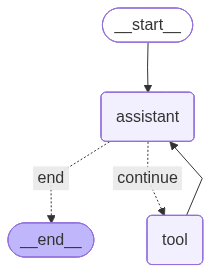

In [14]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.tools import tool

# 关键节点：ToolNode
from langgraph.prebuilt import ToolNode
from langchain_core.runnables import RunnableConfig

# 加载模型配置
_ = load_dotenv()

# 加载模型
llm = ChatOpenAI(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url=os.getenv("DEEPSEEK_BASE_URL"),
    model="deepseek-chat",
    temperature=0.7,
)

# 工具函数
@tool
def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

# 创建工具节点
tools = [get_weather]
tool_node = ToolNode(tools)

# 创建带工具的LLM助手节点
def assistant(state: MessagesState, config: RunnableConfig):
    system_prompt = 'You are a helpful assistant that can check weather.'
    all_messages = [SystemMessage(system_prompt)] + state['messages']
    model = llm.bind_tools(tools)
    return {'messages': [model.invoke(all_messages)]}

# 创建条件边
def should_continue(state: MessagesState, config: RunnableConfig):
    messages = state['messages']
    last_message = messages[-1]
    # 如果最后一条消息是LL决定使用工具调用，则继续
    if last_message.tool_calls:
        return 'continue'
    # 否则，结束
    return 'end'

# 创建图
builder = StateGraph(MessagesState)

# 添加节点
builder.add_node('assistant', assistant)
builder.add_node('tool', tool_node)

# 添加边（从START到assistant）
builder.add_edge(START, 'assistant')

# 添加条件边（根据assistant的输出，决定是否调用工具）
builder.add_conditional_edges(
    # 条件边连接的节点  
    'assistant', 
    # 条件边判断逻辑
    should_continue,
    # 条件边判断逻辑为True时，调用tool节点
    {
        'continue': 'tool',
        'end': END,
    },
)

# 添加边：调用工具节点后回到assistant
builder.add_edge('tool', 'assistant')

# 编译图
my_graph = builder.compile(name='my-graph')
my_graph

## 状态图

In [ ]:
import os
from dotenv import load_dotenv
from openai import OpenAI
from langchain_core.runnables import RunnableConfig
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime
from langgraph.store.memory import InMemoryStore
from dataclasses import dataclass

EMBED_MODEL = "text-embedding-v4"
EMBED_DIM = 1024

# 加载模型配置
_ = load_dotenv()

# 用于获取text embedding的接口
client = OpenAI(
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
)

# 加载模型
model = ChatOpenAI(
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
    model="qwen3-coder-plus",
    temperature=0.7,
)

# embedding生成函数
def embed(texts: list[str]) -> list[list[float]]:
    response = client.embeddings.create(
        model=EMBED_MODEL,
        input=texts,
        dimensions=EMBED_DIM,
    )

    return [item.embedding for item in response.data]

# 测试能否正常生成text embedding
texts = [
    "LangGraph的中间件非常强大",
    "LangGraph的MCP也很好用",
]
vectors = embed(texts)

len(vectors), len(vectors[0])

# InMemoryStore saves data to an in-memory dictionary. Use a DB-backed store in production use.
store = InMemoryStore(index={"embed": embed, "dims": EMBED_DIM})

# 添加两条用户数据
namespace = ("users", )
key = "user_1"
store.put(
    namespace,
    key,
    {
        "rules": [
            "User likes short, direct language",
            "User only speaks English & python",
        ],
        "rule_id": "3",
    },
)

store.put( 
    ("users",),  # Namespace to group related data together (users namespace for user data)
    "user_2",  # Key within the namespace (user ID as key)
    {
        "name": "John Smith",
        "language": "English",
    }  # Data to store for the given user
)

# get the "memory" by ID
item = store.get(namespace, "a-memory") 

# search for "memories" within this namespace, filtering on content equivalence, sorted by vector similarity
items = store.search( 
    namespace, filter={"rule_id": "3"}, query="language preferences"
)

items

@dataclass
class Context:
    user_id: str

@tool
def get_user_info(runtime: ToolRuntime[Context]) -> str:
    """Look up user info."""
    # Access the store - same as that provided to `create_agent`
    store = runtime.store 
    user_id = runtime.context.user_id
    # Retrieve data from store - returns StoreValue object with value and metadata
    user_info = store.get(("users",), user_id) 
    return str(user_info.value) if user_info else "Unknown user"

agent = create_agent(
    model=model,
    tools=[get_user_info],
    # Pass store to agent - enables agent to access store when running tools
    store=store, 
    context_schema=Context
)

# Run the agent
result = agent.invoke(
    {"messages": [{"role": "user", "content": "look up user information"}]},
    context=Context(user_id="user_2") 
)

for message in result['messages']:
    message.pretty_print()

from typing_extensions import TypedDict

# InMemoryStore saves data to an in-memory dictionary. Use a DB-backed store in production.
store = InMemoryStore() 

@dataclass
class Context:
    user_id: str

# TypedDict defines the structure of user information for the LLM
class UserInfo(TypedDict):
    name: str

# Tool that allows agent to update user information (useful for chat applications)
@tool
def save_user_info(user_info: UserInfo, runtime: ToolRuntime[Context]) -> str:
    """Save user info."""
    # Access the store - same as that provided to `create_agent`
    store = runtime.store 
    user_id = runtime.context.user_id 
    # Store data in the store (namespace, key, data)
    store.put(("users",), user_id, user_info) 
    return "Successfully saved user info."

agent = create_agent(
    model=model,
    tools=[save_user_info],
    store=store,
    context_schema=Context
)

# Run the agent
agent.invoke(
    {"messages": [{"role": "user", "content": "My name is John Smith"}]},
    # user_id passed in context to identify whose information is being updated
    context=Context(user_id="user_123") 
)

# You can access the store directly to get the value
store.get(("users",), "user_123").value

## 记忆

In [4]:
import os
import uuid
import sqlite3

from typing import Callable
from dotenv import load_dotenv
from dataclasses import dataclass
from langchain_openai import ChatOpenAI
from langchain.tools import tool, ToolRuntime
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, wrap_model_call, ModelRequest, ModelResponse, SummarizationMiddleware
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.store.sqlite import SqliteStore

# 加载模型配置
_ = load_dotenv()

# 加载模型
llm = ChatOpenAI(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url=os.getenv("DEEPSEEK_BASE_URL"),
    model="deepseek-chat",
    temperature=0.7,
)

@dynamic_prompt
def state_aware_prompt(request: ModelRequest) -> str:
    # request.messages is a shortcut for request.state["messages"]
    message_count = len(request.messages)

    base = "You are a helpful assistant."

    if message_count > 7:
        base += "\nThis is a long conversation - be extra concise."

    # 临时打印base看效果
    print(base)

    return base

agent = create_agent(
    model=llm,
    middleware=[state_aware_prompt]
)

result = agent.invoke(
    {"messages": [
        {"role": "user", "content": "广州今天的天气怎么样？"},
        {"role": "assistant", "content": "广州天气很好"},
        {"role": "user", "content": "吃点什么好呢"},
        {"role": "assistant", "content": "要不要吃香茅鳗鱼煲"},
        {"role": "user", "content": "香茅是什么"},
        {"role": "assistant", "content": "香茅又名柠檬草，常见于泰式冬阴功汤、越南烤肉"},
        {"role": "user", "content": "auv 那还等什么，咱吃去吧"},
    ]},
)

for message in result['messages']:
    message.pretty_print()

You are a helpful assistant.
================================ Human Message =================================

广州今天的天气怎么样？
================================== Ai Message ==================================

广州天气很好
================================ Human Message =================================

吃点什么好呢
================================== Ai Message ==================================

要不要吃香茅鳗鱼煲
================================ Human Message =================================

香茅是什么
================================== Ai Message ==================================

香茅又名柠檬草，常见于泰式冬阴功汤、越南烤肉
================================ Human Message =================================

auv 那还等什么，咱吃去吧
================================== Ai Message ==================================

哈哈，走起！记得找家评价好的东南亚餐厅，香茅鳗鱼煲配碗椰香米饭，绝了～ 😋


## state 管理上下文

In [ ]:
@dataclass
class Context:
    user_id: str

@dynamic_prompt
def store_aware_prompt(request: ModelRequest) -> str:
    user_id = request.runtime.context.user_id

    # Read from Store: get user preferences
    store = request.runtime.store

    # 在preferences空间中查找键为$user_id$的值
    user_prefs = store.get(("preferences",), user_id)

    base = "You are a helpful assistant."

    if user_prefs:
        style = user_prefs.value.get("communication_style", "balanced")
        base += f"\nUser prefers {style} responses."

    return base

store = InMemoryStore()

agent = create_agent(
    model=llm,
    middleware=[store_aware_prompt],
    context_schema=Context,
    store=store,
)

# 预置两条偏好信息
store.put(("preferences",), "user_1", {"communication_style": "Chinese"})
store.put(("preferences",), "user_2", {"communication_style": "Korean"})

# 用户1喜欢中文回复
result = agent.invoke(
    {"messages": [
        {"role": "system", "content": "You are a helpful assistant. Please be extra concise."},
        {"role": "user", "content": 'What is a "hold short line"?'}
    ]},
    context=Context(user_id="user_1"),
)

for message in result['messages']:
    message.pretty_print()

## store管理上下文

In [ ]:
@dataclass
class Context:
    user_role: str
    deployment_env: str

@dynamic_prompt
def context_aware_prompt(request: ModelRequest) -> str:
    # Read from Runtime Context: user role and environment
    user_role = request.runtime.context.user_role
    env = request.runtime.context.deployment_env

    base = "You are a helpful assistant."

    if user_role == "admin":
        base += "\nYou can use the get_weather tool."
    else:
        base += "\nYou are prohibited from using the get_weather tool."

    if env == "production":
        base += "\nBe extra careful with any data modifications."

    return base

@tool
def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

agent = create_agent(
    model=llm,
    tools=[get_weather],
    middleware=[context_aware_prompt],
    context_schema=Context,
    checkpointer=InMemorySaver(),
)

## Runtime管理上下文
runtime 是模型看不见的一些中间件实施条件，用户传入参数等等，用来控制流程。而message是agent真正能看到的prompt等等

In [ ]:
@dataclass
class FileContext:
    uploaded_files: list[dict]

@wrap_model_call
def inject_file_context(
    # 传入参数：整个modelrequest和下一个处理器
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Inject context about files user has uploaded this session."""
    uploaded_files = request.runtime.context.uploaded_files

# 提取文件路径
    try:
        base_dir = os.path.dirname(os.path.abspath(__file__))
    except Exception as e:
        import ipynbname
        import os
        notebook_path = ipynbname.path()
        base_dir = os.path.dirname(notebook_path)

# 存放结构化文本块

    file_sections = []
    for file in uploaded_files:
        # 初始化文件名和文件类型
        name, ftype = "", ""
        path = file.get("path")
        if path:
            base_filename = os.path.basename(path)
            stem, ext = os.path.splitext(base_filename)
            name = stem or base_filename
            ftype = (ext.lstrip(".") if ext else None)

            # 构建文件描述内容
            content_list = [f"名称: {name}"]
            if ftype:
                content_list.append(f"类型: {ftype}")

            # 解析相对路径为绝对路径
            abs_path = path if os.path.isabs(path) else os.path.join(base_dir, path)

            # 读取文件内容
            content_block = ""
            if abs_path and os.path.exists(abs_path):
                try:
                    with open(abs_path, "r", encoding="utf-8") as f:
                        content_block = f.read()
                except Exception as e:
                    content_block = f"[读取文件错误 '{abs_path}': {e}]"
            else:
                content_block = "[文件路径缺失或未找到]"

            section = (
                f"---\n"
                f"{chr(10).join(content_list)}\n\n"
                f"{content_block}\n"
                f"---"
            )
            file_sections.append(section)

        file_context = (
            "已加载的会话文件：\n"
            f"{chr(10).join(file_sections)}"
            "\n回答问题时请参考这些文件。"
        )

        # Inject file context before recent messages
        messages = [  
            *request.messages,
            {"role": "user", "content": file_context},
        ]
        request = request.override(messages=messages)  

    # 交给下一个处理器
    return handler(request)

agent = create_agent(
    model=llm,
    middleware=[inject_file_context],
    context_schema=FileContext,
)

## 动态修改消息列表

In [ ]:
@tool
def fetch_user_data(
    user_id: str,
    runtime: ToolRuntime
) -> str:
    """
    Fetch user information from the in-memory store.

    :param user_id: The unique identifier of the user.
    :param runtime: The tool runtime context injected by the framework.
    :return: The user's description string if found; an empty string otherwise.
    """
    store = runtime.store
    user_info = store.get(("user_info",), user_id)

    user_desc = ""
    if user_info:
        user_desc = user_info.value.get("description", "")

    return user_desc

agent = create_agent(
    model=llm,
    tools=[fetch_user_data],
    store=store,
)

## 在工具中使用上下文

In [ ]:
# 创建短期记忆
checkpointer = InMemorySaver()

# 创建带内置摘要中间件的Agent
# 为了让配置能在我们的例子里生效，这里的触发值设得很小
agent = create_agent(
    model=llm,
    middleware=[
        SummarizationMiddleware(
            model=llm,
            max_tokens_before_summary=40,  # Trigger summarization at 40 tokens
            messages_to_keep=1,  # Keep last 1 messages after summary
        ),
    ],
)

## langchain自带的上下文压缩中间件

In [ ]:
# System prompt to steer the agent to be an expert researcher
research_instructions = """你是一名资深研究员。你的工作是进行全面深入的研究，并撰写一份精炼的报告。

你可以使用互联网搜索工具作为获取信息的主要方式。

## `internet_search`

使用该工具对指定查询进行互联网搜索。你可以设置返回结果的最大数量。

对于该工具的 query 参数，每次最多输入 **2个** 关键词。且关键词之间必须用空格分开。若不遵守此条规定，工具将返回无意义内容。

正确用例：

- 南京
- 美食 四川

错误用例：

- 美食 四川 2025

注意，当关键词数量为2个的时候，必须将2个词中更重要的那个放在前面。
"""

@tool
def get_today_date() -> str:
    """获取今天的日期"""
    return datetime.now().strftime("%Y-%m-%d")

agent = create_deep_agent(
    model=llm,
    tools=[internet_search, get_today_date],
    system_prompt=research_instructions
)

## Deepagent
create_deep_agent相比create_agent，更适合研究型任务，create_agent更适合assistant任务